# Thuật toán Hồi quy Logistic (Logistic Regression) từ đầu (From Scratch)

Mục tiêu của notebook này:
1. Lập trình mô hình Hồi quy Logistic bằng phương pháp hạ độ dốc (gradient descent) trực tiếp trên ma trận thưa.
2. Sử dụng hàm sigmoid chống tràn số và hàm mất mát Binary Cross-Entropy.
3. Tìm kiếm siêu tham số tốc độ học `learning_rate` (lr), n_iters bằng phương pháp Grid Search.
4. Vẽ biểu đồ đường cong học tập (Learning Curve) thể hiện giá trị mất mát giảm dần qua các epochs để kiểm chứng độ hội tụ.
5. Đánh giá mô hình chi tiết (Classification Report, Confusion Matrix, ROC-AUC).


In [1]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc


### Bước 1. Tải dữ liệu đặc trưng đã xử lý


In [2]:
print("Đang tải dữ liệu đặc trưng...")
X_train = sp.load_npz('../data/ready_train/X_train_final.npz')
X_test = sp.load_npz('../data/ready_train/X_test_final.npz')
y_train = pd.read_pickle('../data/ready_train/y_train.pkl').values
y_test = pd.read_pickle('../data/ready_train/y_test.pkl').values

print(f"Kích thước tập huấn luyện X_train: {X_train.shape}")
print(f"Kích thước tập kiểm thử X_test   : {X_test.shape}")


Đang tải dữ liệu đặc trưng...


Kích thước tập huấn luyện X_train: (31323, 3500)
Kích thước tập kiểm thử X_test   : (7831, 3500)


### Bước 2. Lập trình lớp Logistic Regression từ đầu tối ưu cho Ma trận thưa

Sử dụng phép nhân ma trận thưa `.dot()` để tăng tốc độ tính toán.


In [3]:
class LogisticRegressionFromScratch:
    def __init__(self, lr=0.1, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.w = None
        self.b = None
        self.loss_history = []
        
    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -20, 20)))
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.loss_history = []
        
        y = np.array(y).ravel()
        
        for i in range(self.n_iters):
            z = X.dot(self.w) + self.b
            y_pred = self._sigmoid(z)
            
            eps = 1e-15
            loss = -np.mean(y * np.log(y_pred + eps) + (1 - y) * np.log(1 - y_pred + eps))
            self.loss_history.append(loss)
            
            dw = (1 / n_samples) * X.T.dot(y_pred - y)
            db = (1 / n_samples) * np.sum(y_pred - y)
            
            self.w -= self.lr * dw
            self.b -= self.lr * db
            
    def predict_proba(self, X):
        z = X.dot(self.w) + self.b
        return self._sigmoid(z)
        
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(float)

### Bước 3. Tìm kiếm siêu tham số learning_rate (lr) và Trực quan hóa các đường cong học tập

Chúng ta thử nghiệm Grid Search với  **`learning_rate` $\in \{0.001, 0.01, 0.1, 0.5\}$**, **`n_iters` $\in \{500, 1000, 1500, 2000\}$** và chạy best n_iters để so sánh tốc độ hội tụ của các giá trị.


=== BẮT ĐẦU GRID SEARCH TÌM SIÊU THAM SỐ TỐI ƯU ===



lr = 0.001 | n_iters = 500  | Test Accuracy: 81.66% | Final Loss: 0.6535 | Thời gian: 5.24s


lr = 0.001 | n_iters = 1000 | Test Accuracy: 82.11% | Final Loss: 0.6196 | Thời gian: 8.53s


lr = 0.001 | n_iters = 1500 | Test Accuracy: 83.35% | Final Loss: 0.5902 | Thời gian: 12.85s


lr = 0.001 | n_iters = 2000 | Test Accuracy: 87.03% | Final Loss: 0.5641 | Thời gian: 17.13s


...

lr = 0.1   | n_iters = 2000 | Test Accuracy: 95.20% | Final Loss: 0.1301 | Thời gian: 18.25s


lr = 0.5   | n_iters = 500  | Test Accuracy: 95.31% | Final Loss: 0.1218 | Thời gian: 4.56s


lr = 0.5   | n_iters = 1000 | Test Accuracy: 96.18% | Final Loss: 0.0972 | Thời gian: 9.16s


lr = 0.5   | n_iters = 1500 | Test Accuracy: 96.85% | Final Loss: 0.0837 | Thời gian: 13.65s


lr = 0.5   | n_iters = 2000 | Test Accuracy: 97.46% | Final Loss: 0.0747 | Thời gian: 18.40s

=== ĐANG VẼ BIỂU ĐỒ HỘI TỤ VỚI N_ITERS = 2000 ===


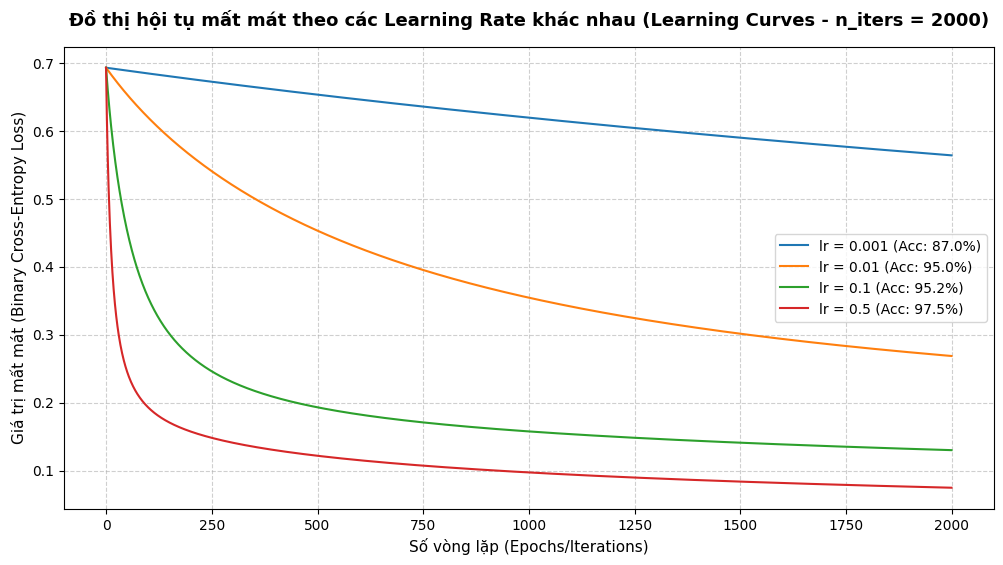


=> Siêu tham số tốt nhất được lựa chọn: lr = 0.5, n_iters = 2000 (Độ chính xác: 97.46%)


In [4]:
print("=== BẮT ĐẦU GRID SEARCH TÌM SIÊU THAM SỐ TỐI ƯU ===\n")

lr_candidates = [0.001, 0.01, 0.1, 0.5]
n_iters_candidates = [500, 1000, 1500, 2000]

best_acc = -1
best_lr = None
best_n_iters = None

plt.figure(figsize=(12, 6))

# Chạy grid search thử nghiệm các tổ hợp
for lr_val in lr_candidates:
    for n_iters_val in n_iters_candidates:
        t_start = time.time()
        model = LogisticRegressionFromScratch(lr=lr_val, n_iters=n_iters_val)
        model.fit(X_train, y_train)
        preds_test = model.predict(X_test)
        acc = np.mean(preds_test == y_test) * 100
        t_end = time.time()
        
        print(f"lr = {lr_val:<5} | n_iters = {n_iters_val:<4} | Test Accuracy: {acc:.2f}% | Final Loss: {model.loss_history[-1]:.4f} | Thời gian: {t_end - t_start:.2f}s")
        
        if acc > best_acc:
            best_acc = acc
            best_lr = lr_val
            best_n_iters = n_iters_val

# Vẽ biểu đồ hội tụ (Learning Curve) cho các learning rate với số vòng lặp tối đa (2000)
print(f"\n=== ĐANG VẼ BIỂU ĐỒ HỘI TỤ VỚI N_ITERS = {best_n_iters} ===")
for lr_val in lr_candidates:
    model = LogisticRegressionFromScratch(lr=lr_val, n_iters=best_n_iters)
    model.fit(X_train, y_train)
    preds_test = model.predict(X_test)
    acc = np.mean(preds_test == y_test) * 100
    plt.plot(model.loss_history, label=f'lr = {lr_val} (Acc: {acc:.1f}%)', linewidth=1.5)

plt.title(f"Đồ thị hội tụ mất mát theo các Learning Rate khác nhau (Learning Curves - n_iters = {best_n_iters})", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Số vòng lặp (Epochs/Iterations)", fontsize=11)
plt.ylabel("Giá trị mất mát (Binary Cross-Entropy Loss)", fontsize=11)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"\n=> Siêu tham số tốt nhất được lựa chọn: lr = {best_lr}, n_iters = {best_n_iters} (Độ chính xác: {best_acc:.2f}%)")

### Bước 4. Huấn luyện mô hình Logistic Regression tối ưu với best epochs và Đánh giá thời gian


In [5]:
print(f"Huấn luyện mô hình tối ưu với lr = {best_lr} trong {best_n_iters} vòng lặp...")
lr_optimal = LogisticRegressionFromScratch(lr=best_lr, n_iters=best_n_iters)

# Đo thời gian huấn luyện (fit)
t0_fit = time.time()
lr_optimal.fit(X_train, y_train)
t1_fit = time.time()
train_time_ms = (t1_fit - t0_fit) * 1000
print(f"Thời gian huấn luyện (fit): {train_time_ms:.2f} ms")

# Đo thời gian dự báo (predict) trên toàn bộ tập test
t0_pred = time.time()
y_pred = lr_optimal.predict(X_test)
t1_pred = time.time()
predict_time_ms = (t1_pred - t0_pred) * 1000
print(f"Thời gian dự báo (predict): {predict_time_ms:.2f} ms")

Huấn luyện mô hình tối ưu với lr = 0.5 trong 2000 vòng lặp...


Thời gian huấn luyện (fit): 18657.82 ms
Thời gian dự báo (predict): 1.97 ms


### Bước 5. Báo cáo phân loại & Ma trận nhầm lẫn (Confusion Matrix)



=== ĐÁNH GIÁ ĐỐI SÁNH HIỆU NĂNG THEO CÁC NGƯỠNG QUYẾT ĐỊNH ===


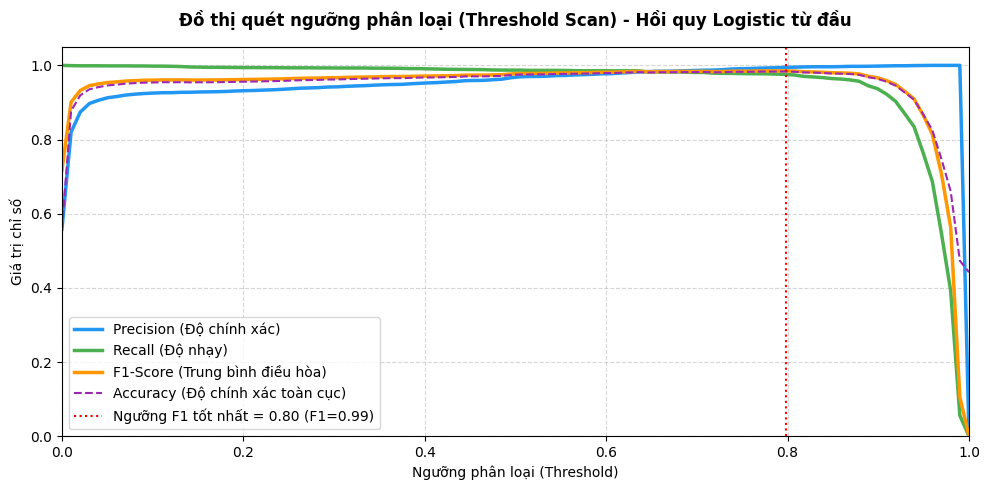


--- KẾT QUẢ QUÉT NGƯỠNG TỐI ƯU ---
Ngưỡng tối ưu theo F1-score: 0.7980 (F1-score = 0.9851)
Tại ngưỡng này: Precision = 0.9946, Recall = 0.9757, Accuracy = 0.9835

=== BÁO CÁO PHÂN LOẠI CHI TIẾT (THRESHOLD = 0.5 - MẶC ĐỊNH) ===
              precision    recall  f1-score   support

    Spam (1)       0.97      0.99      0.98      4369
Not Spam (0)       0.98      0.96      0.97      3462

    accuracy                           0.97      7831
   macro avg       0.98      0.97      0.97      7831
weighted avg       0.97      0.97      0.97      7831


=== BÁO CÁO PHÂN LOẠI CHI TIẾT (THRESHOLD = 0.7980 - TỐI ƯU F1) ===
              precision    recall  f1-score   support

    Spam (1)       0.99      0.98      0.99      4369
Not Spam (0)       0.97      0.99      0.98      3462

    accuracy                           0.98      7831
   macro avg       0.98      0.98      0.98      7831
weighted avg       0.98      0.98      0.98      7831



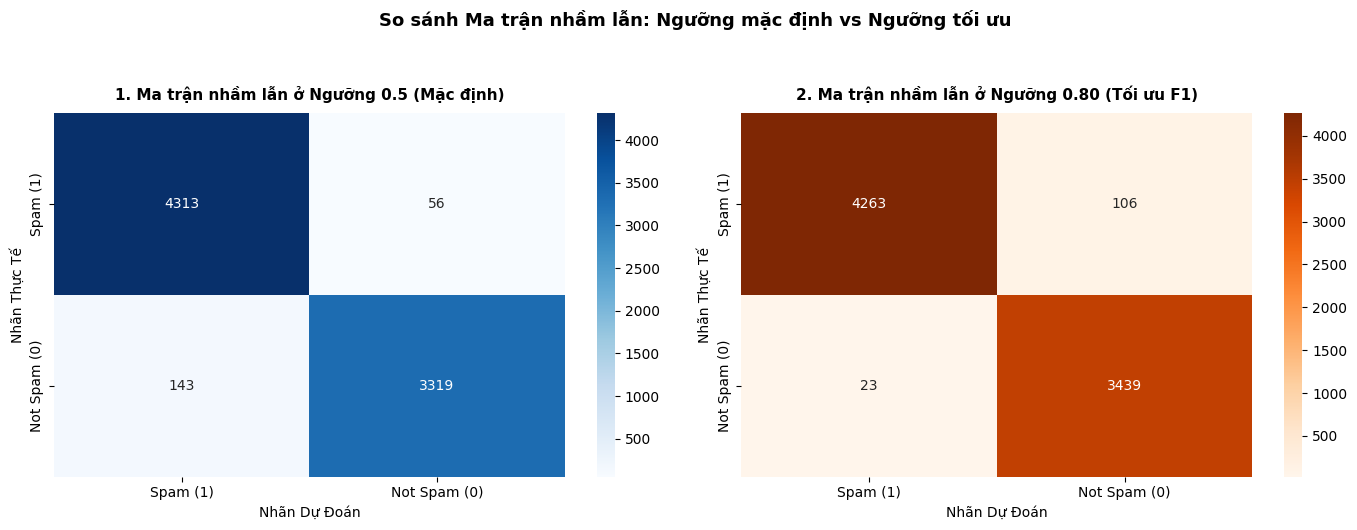

In [6]:
print("\n=== ĐÁNH GIÁ ĐỐI SÁNH HIỆU NĂNG THEO CÁC NGƯỠNG QUYẾT ĐỊNH ===")

from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Lấy xác suất dự báo lớp Spam (1) từ mô hình
y_probs = lr_optimal.predict_proba(X_test)

# 2. Tiến hành quét ngưỡng phân loại (Threshold Scan) chi tiết từ 0.0 đến 1.0
thresholds = np.linspace(0.0, 1.0, 100)
precisions = []
recalls = []
f1_scores = []
accuracies = []

for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, pos_label=1, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, pos_label=1, zero_division=0))
    f1_scores.append(f1_score(y_test, y_pred_t, pos_label=1, zero_division=0))
    accuracies.append(accuracy_score(y_test, y_pred_t))

# Tìm ngưỡng tối ưu theo F1-Score cao nhất
best_idx = np.argmax(f1_scores)
best_t = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

# 3. Vẽ biểu đồ quét ngưỡng
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions, label='Precision (Độ chính xác)', color='#2196F3', linewidth=2.5)
plt.plot(thresholds, recalls, label='Recall (Độ nhạy)', color='#4CAF50', linewidth=2.5)
plt.plot(thresholds, f1_scores, label='F1-Score (Trung bình điều hòa)', color='#FF9800', linewidth=2.5)
plt.plot(thresholds, accuracies, label='Accuracy (Độ chính xác toàn cục)', color='#9C27B0', linestyle='--', linewidth=1.5)

plt.axvline(best_t, color='red', linestyle=':', label=f'Ngưỡng F1 tốt nhất = {best_t:.2f} (F1={best_f1:.2f})')

plt.title('Đồ thị quét ngưỡng phân loại (Threshold Scan) - Hồi quy Logistic từ đầu', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Ngưỡng phân loại (Threshold)', fontsize=10)
plt.ylabel('Giá trị chỉ số', fontsize=10)
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"\n--- KẾT QUẢ QUÉT NGƯỠNG TỐI ƯU ---")
print(f"Ngưỡng tối ưu theo F1-score: {best_t:.4f} (F1-score = {best_f1:.4f})")
print(f"Tại ngưỡng này: Precision = {precisions[best_idx]:.4f}, Recall = {recalls[best_idx]:.4f}, Accuracy = {accuracies[best_idx]:.4f}")

# 4. So sánh Confusion Matrix ở ngưỡng mặc định (0.5) và ngưỡng tốt nhất (best_t)
y_pred_05 = (y_probs >= 0.5).astype(int)
y_pred_best = (y_probs >= best_t).astype(int)

cm_05 = confusion_matrix(y_test, y_pred_05, labels=[1, 0])
cm_best = confusion_matrix(y_test, y_pred_best, labels=[1, 0])

print("\n=== BÁO CÁO PHÂN LOẠI CHI TIẾT (THRESHOLD = 0.5 - MẶC ĐỊNH) ===")
print(classification_report(y_test, y_pred_05, labels=[1, 0], target_names=['Spam (1)', 'Not Spam (0)']))

print(f"\n=== BÁO CÁO PHÂN LOẠI CHI TIẾT (THRESHOLD = {best_t:.4f} - TỐI ƯU F1) ===")
print(classification_report(y_test, y_pred_best, labels=[1, 0], target_names=['Spam (1)', 'Not Spam (0)']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap cho ngưỡng 0.5
sns.heatmap(cm_05, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Spam (1)', 'Not Spam (0)'], 
            yticklabels=['Spam (1)', 'Not Spam (0)'])
axes[0].set_title('1. Ma trận nhầm lẫn ở Ngưỡng 0.5 (Mặc định)', fontsize=11, fontweight='bold', pad=10)
axes[0].set_xlabel('Nhãn Dự Đoán')
axes[0].set_ylabel('Nhãn Thực Tế')

# Heatmap cho ngưỡng best_t
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Spam (1)', 'Not Spam (0)'], 
            yticklabels=['Spam (1)', 'Not Spam (0)'])
axes[1].set_title(f'2. Ma trận nhầm lẫn ở Ngưỡng {best_t:.2f} (Tối ưu F1)', fontsize=11, fontweight='bold', pad=10)
axes[1].set_xlabel('Nhãn Dự Đoán')
axes[1].set_ylabel('Nhãn Thực Tế')

plt.suptitle('So sánh Ma trận nhầm lẫn: Ngưỡng mặc định vs Ngưỡng tối ưu', fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


### Bước 6. Vẽ Đường cong ROC-AUC


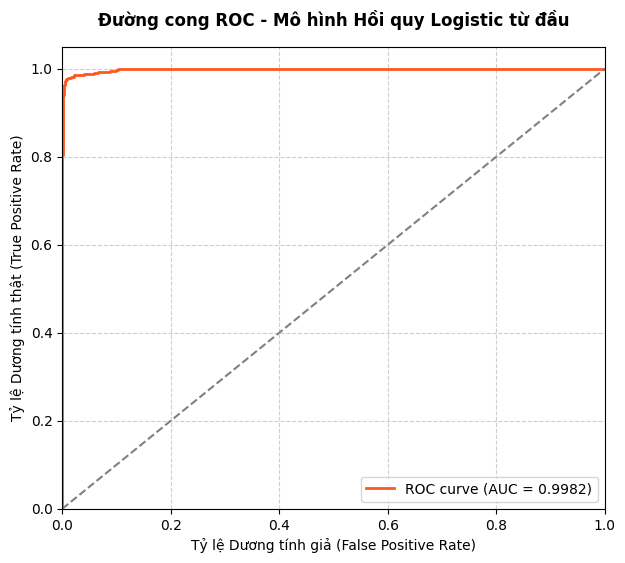

In [7]:
y_probs = lr_optimal.predict_proba(X_test)
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#FF5722', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tỷ lệ Dương tính giả (False Positive Rate)')
plt.ylabel('Tỷ lệ Dương tính thật (True Positive Rate)')
plt.title('Đường cong ROC - Mô hình Hồi quy Logistic từ đầu', fontsize=12, fontweight='bold', pad=15)
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [8]:
import pickle

# Sử dụng ngưỡng tối ưu tìm được từ bước quét ngưỡng (nếu không có thì mặc định 0.5)
best_threshold = best_t if 'best_t' in globals() else 0.5

# Gom tất cả vào một dictionary
model_artifacts = {
    'model': lr_optimal,
    'threshold': best_threshold
}

# Lưu file
with open('logistic_model.pkl', 'wb') as f:
    pickle.dump(model_artifacts, f)

print(f"Đã lưu thành công mô hình và threshold tối ưu ({best_threshold:.4f})!")


Đã lưu thành công mô hình và threshold tối ưu (0.7980)!
